In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
import tensorflow as tf

In [4]:
from tensorflow import keras

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
mnist = keras.datasets.mnist

In [17]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [21]:
print(x_train.shape)

(60000, 28, 28)


In [23]:
x_train,x_test=x_train/255.0,x_test/255.0

In [51]:
model=keras.Sequential ([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10,activation="softmax")
])

In [57]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [59]:
model.fit(x_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8571 - loss: 0.4892
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9549 - loss: 0.1529
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9679 - loss: 0.1072
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9718 - loss: 0.0901
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9765 - loss: 0.0740


In [63]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)

313/313 - 1s - 5ms/step - accuracy: 0.9756 - loss: 0.0792


Test accuracy:0.9756
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


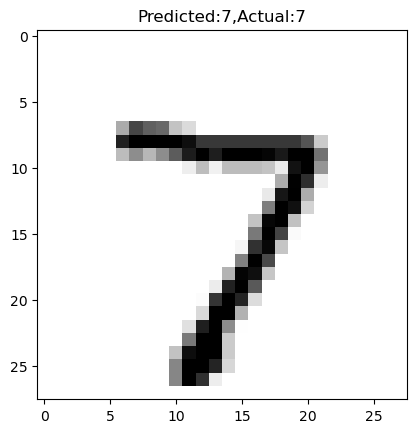

In [73]:
print(f"Test accuracy:{test_acc:.4f}")
prediction=model.predict(x_test)
plt.imshow(x_test[0],cmap=plt.cm.binary)
plt.title(f"Predicted:{np.argmax(prediction[0])},Actual:{y_test[0]}")
plt.show()